In [1]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, average_precision_score
from pyod.utils.data import precision_n_scores
from pyod.models.iforest import IForest
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from pyod.models.xgbod import XGBOD
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [2]:
def evaluate_metrics(y_test, y_pred, y_proba=None, digits=3):
    res = {"Accuracy": round(accuracy_score(y_test, y_pred), digits),
           "Precision": round(precision_score(y_test, y_pred), digits),
           "Recall": round(recall_score(y_test, y_pred), digits),
           "F1": round(f1_score(y_test, y_pred), digits),
           "MCC": round(matthews_corrcoef(y_test, y_pred), ndigits=digits)}
    if y_proba is not None:
        res["AUC_PR"] = round(average_precision_score(y_test, y_proba), digits)
        res["AUC_ROC"] = round(roc_auc_score(y_test, y_proba), digits)
        res["PREC_N_SCORES"] = round(precision_n_scores(y_test, y_proba), digits)
    return res


def set_seed_numpy(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

In [3]:
features = [
    "mean", "var", "std", "len", "duration", "len_weighted", "gaps_squared", "n_peaks",
    "smooth10_n_peaks", "smooth20_n_peaks", "var_div_duration", "var_div_len",
    "diff_peaks", "diff2_peaks", "diff_var", "diff2_var", "kurtosis", "skew",
]
SEED = 2137


In [4]:
df = pd.read_csv("data/dataset.csv", index_col="segment")

X_train, y_train = df.loc[df.train==1, features], df.loc[df.train==1, "anomaly"]

X_test, y_test = df.loc[df.train==0, features], df.loc[df.train==0, "anomaly"]

X_train_nominal = df.loc[(df.anomaly==0)&(df.train==1), features]

#standardize the data to have a mean of 0 and a standard deviation of 1
#useful when values are in different units, varying length, and sampling frequency
prep = StandardScaler()
X_train_nominal2 = prep.fit_transform(X_train_nominal)
X_train2 = prep.transform(X_train)
X_test2 = prep.transform(X_test)

In [5]:
set_seed_numpy(SEED)

In [6]:
# supervised example

In [7]:
import shap

c:\Users\vill799\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
shap.initjs()

In [9]:
model = AdaBoostClassifier(random_state=SEED)
model.fit(X_train2, y_train)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

AdaBoostClassifier(random_state=2137) 
 {'Accuracy': 0.936, 'Precision': 0.891, 'Recall': 0.796, 'F1': 0.841, 'MCC': 0.803, 'AUC_PR': 0.926, 'AUC_ROC': 0.966, 'PREC_N_SCORES': 0.841}


In [10]:
print("y_predicted (first 60):", y_predicted[:60])
print("y_predicted_score (first 60):", y_predicted_score[:60])

y_predicted (first 60): [0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0
 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1]
y_predicted_score (first 60): [-0.55148131 -0.40507925 -0.55148131  0.34552095 -0.33010038 -0.20267919
  1.05968696 -0.27814103  0.16915371 -0.20267919 -0.40507925  0.16915371
  0.24466088 -0.27814103 -0.42454309 -0.49952196 -0.55148131 -0.40507925
 -0.55148131 -0.49952196 -0.49952196 -0.47650244 -0.55148131 -0.55148131
 -0.55148131 -0.40507925 -0.42454309  0.6047504   0.02275165  0.30855846
 -0.47650244  0.69919311 -0.47650244  0.84477505 -0.55148131 -0.55148131
 -0.2971219  -0.55148131 -0.55148131 -0.20267919 -0.55148131 -0.40507925
  0.98417979  0.69919311 -0.40507925  0.86037004  0.98417979  1.05968696
 -0.55148131 -0.08586779 -0.46472209 -0.73279129 -0.73279129 -0.74955505
 -0.74955505 -0.67936616  0.32393911  0.60616575  0.63955026  0.17393674]


In [11]:
print(df['anomaly'].value_counts())

anomaly
0    1689
1     434
Name: count, dtype: int64


In [12]:
X_explain = X_test2[:100]

explainer = shap.KernelExplainer(
    model.decision_function, shap.sample(X_train2, 100, random_state=SEED)
)

shap_values = explainer(X_explain)

100%|██████████| 100/100 [01:17<00:00,  1.29it/s]


C:\Users\vill799\AppData\Local\Temp\ipykernel_21656\2991189802.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain)


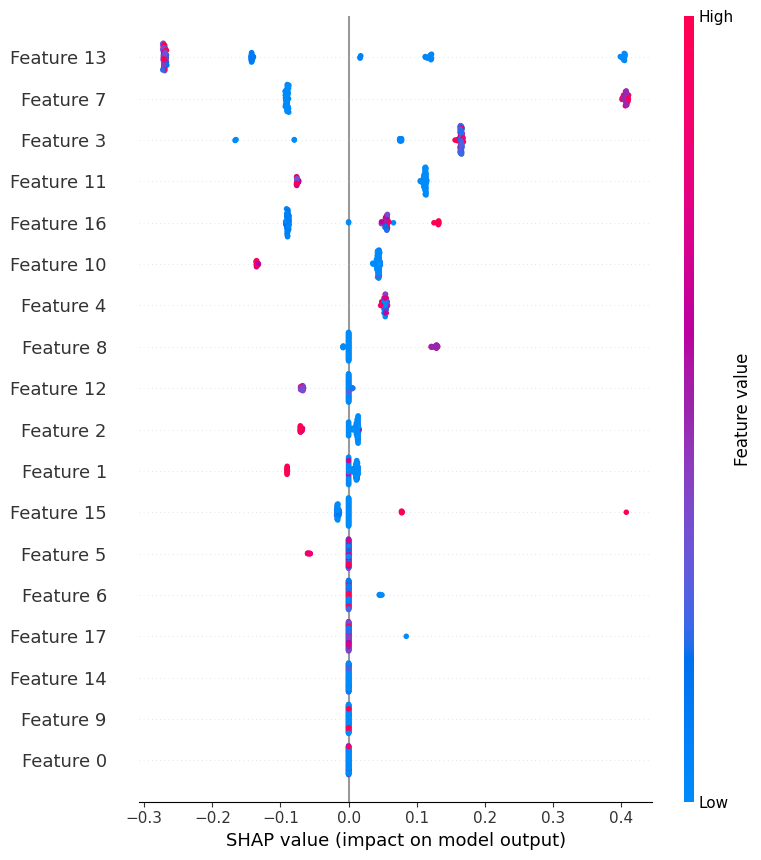

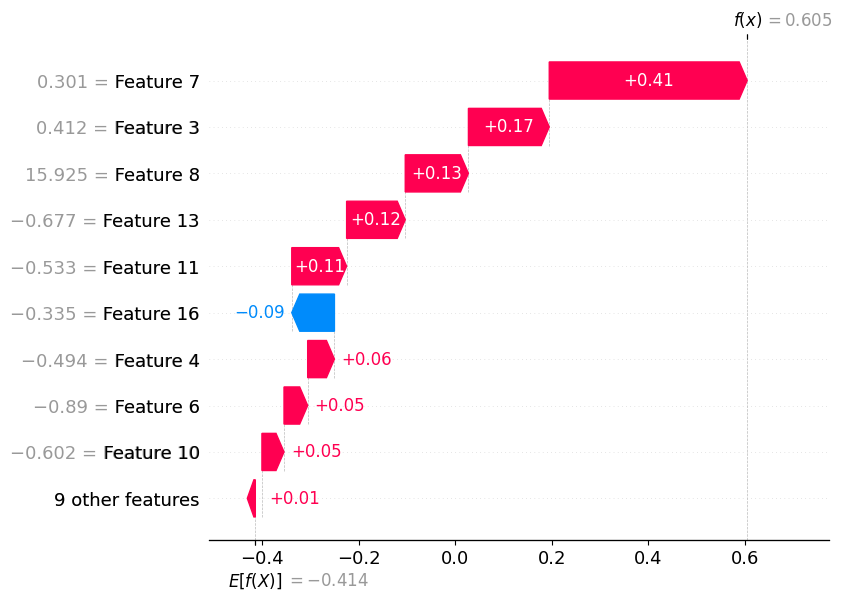

In [13]:
shap.summary_plot(shap_values, X_explain)
shap.waterfall_plot(shap_values[27])
shap.plots.force(shap_values[27])
#shap.plots.force(shap_values)

In [14]:
i = 27
print("SHAP values for sample 0:", shap_values.values[i])

print("\nBase value:", shap_values.base_values[i])
print("Sum of SHAP values:", shap_values.values[i].sum())
print("Base + sum(SHAP):", shap_values.base_values[i] + shap_values.values[i].sum())

SHAP values for sample 0: [ 0.          0.01369916  0.          0.16738401  0.05540208  0.
  0.04902467  0.40990603  0.13082788  0.          0.04572396  0.1136094
  0.          0.12141186  0.          0.         -0.08836892  0.        ]

Base value: -0.4138697237528637
Sum of SHAP values: 1.018620123348335
Base + sum(SHAP): 0.6047503995954713


In [15]:
y_predicted_explain = model.predict(X_explain)

anomaly_mask = (y_predicted_explain == 1)
normal_mask  = (y_predicted_explain == 0)

shap_anom = shap_values.values[anomaly_mask]
shap_norm = shap_values.values[normal_mask]

# how strongly a feature influences a model's prediction
anom_importance = np.mean(np.abs(shap_anom), axis=0)
norm_importance = np.mean(np.abs(shap_norm), axis=0)

# what direction is the feature pushing the prediction toward(positive or negative)
anom_direction = np.mean(shap_anom, axis=0)
norm_direction = np.mean(shap_norm, axis=0)


df_attack_features = pd.DataFrame({
    "feature": features,
    "anomaly_mean_shap": anom_direction,
    "normal_mean_shap": norm_direction,
    "difference": anom_direction - norm_direction,
    "anomaly_abs_importance": anom_importance
}).sort_values("difference") 

print("Features Driving Anomalous Behavior (most → least):")
print(df_attack_features.sort_values("difference", ascending=False))

Features Driving Anomalous Behavior (most → least):
             feature  anomaly_mean_shap  normal_mean_shap  difference  \
7            n_peaks           0.376203         -0.053814    0.430018   
13       diff2_peaks           0.109474         -0.221833    0.331307   
8   smooth10_n_peaks           0.095683         -0.000699    0.096382   
16          kurtosis           0.031197         -0.042236    0.073433   
11       var_div_len           0.105420          0.059738    0.045682   
10  var_div_duration           0.042633          0.007066    0.035568   
12        diff_peaks          -0.001174         -0.034112    0.032938   
3                len           0.154004          0.132744    0.021260   
2                std           0.010704         -0.008217    0.018921   
1                var           0.010030         -0.006953    0.016983   
15         diff2_var           0.011666         -0.002206    0.013872   
17              skew           0.002644          0.000000    0.002644   

In [ ]:
# unsupervised example

In [ ]:
#model = IForest(random_state=SEED)
#model.fit(X_train2)

#y_predicted = model.predict(X_test2)
#y_predicted_score = model.decision_function(X_test2)

#print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

In [16]:
model = IForest(random_state=SEED, contamination=.2)
model.fit(X_train2)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))


IForest(behaviour='old', bootstrap=False, contamination=0.2, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=2137,
    verbose=0) 
 {'Accuracy': 0.696, 'Precision': 0.289, 'Recall': 0.292, 'F1': 0.291, 'MCC': 0.097, 'AUC_PR': 0.352, 'AUC_ROC': 0.627, 'PREC_N_SCORES': 0.292}


In [18]:
print("y_predicted (first 10):", y_predicted[:60])
print("y_predicted_score (first 10):", y_predicted_score[:60])

y_predicted (first 10): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
y_predicted_score (first 10): [-0.06684861 -0.04099721 -0.07685299 -0.09934064 -0.09051236 -0.09556158
 -0.04657126 -0.08721502 -0.06775141 -0.10294146 -0.07637995 -0.07086155
 -0.06786983 -0.07900203 -0.09794683 -0.09765223 -0.08424824 -0.08138617
 -0.0878894  -0.09075027 -0.09453603 -0.10132808 -0.09543044 -0.09124454
 -0.09662873 -0.08889592 -0.0961481  -0.06676402 -0.0775153  -0.06336275
 -0.10001116 -0.07269742 -0.09484049 -0.10175678 -0.09778412 -0.08883931
 -0.11068907 -0.08276366 -0.07820985 -0.10915132 -0.07968368 -0.0762769
 -0.03219447 -0.05446306 -0.02662572  0.01018483 -0.0264319  -0.0367981
 -0.05092628 -0.09399095  0.08883304  0.03619115  0.09239465  0.01346412
  0.0128076   0.11664507  0.17585598  0.03801451  0.10159382  0.07181146]


In [19]:
print(df['anomaly'].value_counts())

anomaly
0    1689
1     434
Name: count, dtype: int64


C:\Users\vill799\AppData\Local\Temp\ipykernel_21656\3942099924.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test2)


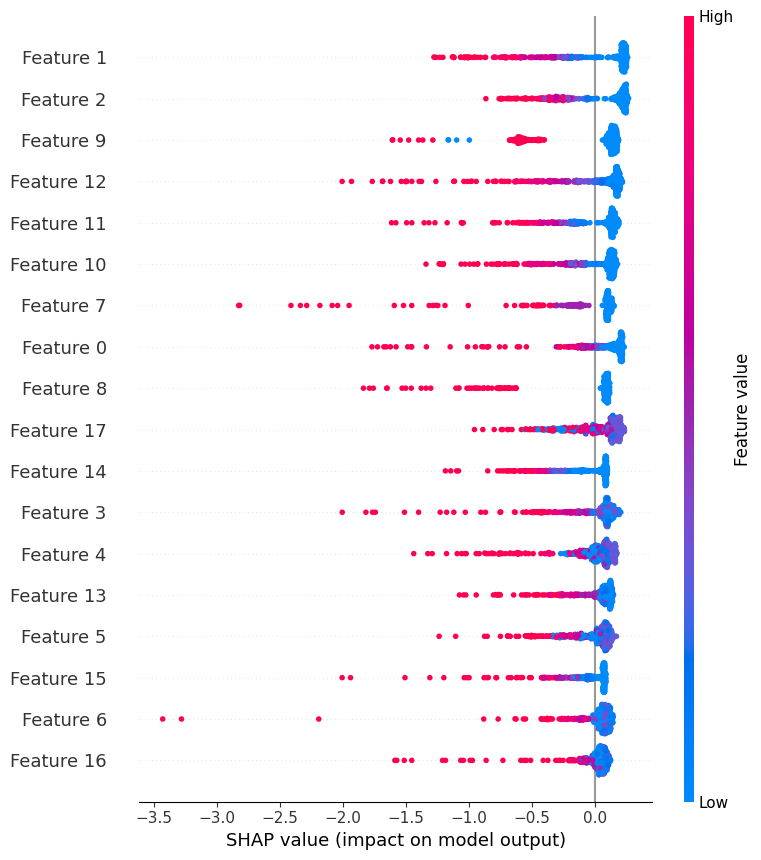

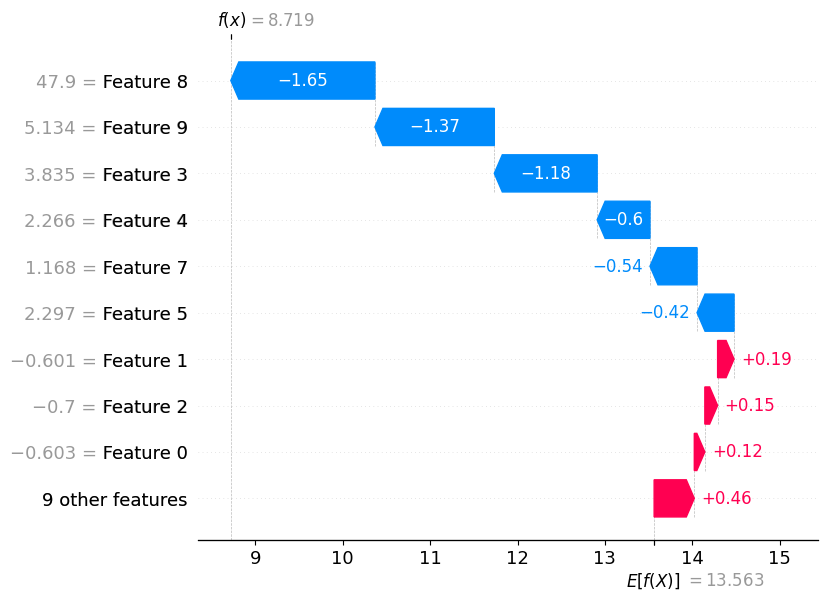

In [20]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test2)

shap.summary_plot(shap_values, X_test2)
shap.waterfall_plot(shap_values[58])

shap.plots.force(shap_values[58])

In [21]:
i = 58
print("SHAP values for sample 0:", shap_values.values[i])

print("\nBase value:", shap_values.base_values[i])
print("Sum of SHAP values:", shap_values.values[i].sum())
print("Base + sum(SHAP):", shap_values.base_values[i] + shap_values.values[i].sum())

SHAP values for sample 0: [ 0.12063391  0.18813093  0.14622092 -1.17684228 -0.6046093  -0.42347163
  0.0701863  -0.53855984 -1.64927745 -1.36595555  0.09721926  0.08030308
  0.1038814   0.00796675  0.05238371  0.06135702  0.06080466 -0.07441932]

Base value: 13.562963817941764
Sum of SHAP values: -4.844047450082915
Base + sum(SHAP): 8.71891636785885


In [22]:
anomaly_mask = y_predicted == 1
normal_mask  = y_predicted == 0

shap_anom = shap_values.values[anomaly_mask]
shap_norm = shap_values.values[normal_mask]

# how strongly a feature influences a model's prediction
anom_importance = np.mean(np.abs(shap_anom), axis=0)
norm_importance = np.mean(np.abs(shap_norm), axis=0)


# what direction is the feature pushing the prediction toward(positive or negative)
anom_direction = np.mean(shap_anom, axis=0)
norm_direction = np.mean(shap_norm, axis=0)


df_attack_features = pd.DataFrame({
    "feature": features,
    "anomaly_mean_shap": anom_direction,
    "normal_mean_shap": norm_direction,
    "difference": anom_direction - norm_direction,
    "anomaly_abs_importance": anom_importance
}).sort_values("difference")

print("Features Driving Anomalous Behavior (most → least):")
print(df_attack_features.to_string(index=False))


Features Driving Anomalous Behavior (most → least):
         feature  anomaly_mean_shap  normal_mean_shap  difference  anomaly_abs_importance
             var          -0.379304          0.099555   -0.478859                0.490077
             std          -0.256074          0.103105   -0.359180                0.339445
         n_peaks          -0.295441          0.046989   -0.342430                0.419908
var_div_duration          -0.294192          0.044011   -0.338203                0.367416
     var_div_len          -0.280606          0.041037   -0.321642                0.348996
            mean          -0.194919          0.125221   -0.320140                0.276201
             len          -0.210254          0.048227   -0.258482                0.292911
        diff_var          -0.252929         -0.013286   -0.239643                0.280921
        duration          -0.195234          0.016515   -0.211748                0.261134
smooth10_n_peaks          -0.178981          0.0